# Comparison

Comparison of the seapopym model 1D (without transport) and the Seapodym-LMTL 3D model.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from seapopym.configuration.no_transport import (
    ForcingParameter,
    ForcingUnit,
    FunctionalGroupParameter,
    FunctionalGroupUnit,
    FunctionalTypeParameter,
    MigratoryTypeParameter,
    NoTransportConfiguration,
)
# from seapopym.logging.custom_logger import set_verbose
from seapopym.model import NoTransportModel
from seapopym.standard import coordinates
from seapopym.standard.units import StandardUnitsLabels

# set_verbose()

## Loading the data

---


## Forcings

In [3]:
# Temperature
path_temp="/data/rd_exchange/sroyer/SEAPOPYM/3D/cmems_mod_glo_bgc_my_0.083deg-lmtl-Fphy_PT1D-i_1749126996464.nc"
ds_temp = xr.open_dataset(path_temp,engine='netcdf4')

temp = ds_temp['T'].sel(depth=1) # Extract temperature in the epipelagic layer depth

In [4]:
temp_papa=temp.mean(dim=['longitude','latitude'],skipna=True)

In [5]:
temperature = xr.DataArray(
    dims=["time", "latitude", "longitude", "layer"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(temp.time)),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
        "layer": coordinates.new_layer([0]),
    },
    attrs={"units": StandardUnitsLabels.temperature},
    data=temp_papa.values[:, np.newaxis, np.newaxis, np.newaxis],
)

In [6]:
# NPP (contain also zooplankcton biomass from 3D simulations)
path_nz="/data/rd_exchange/sroyer/SEAPOPYM/3D/cmems_mod_glo_bgc_my_0.083deg-lmtl_PT1D-i_1749126251183.nc"
ds_nz=xr.open_dataset(path_nz,engine='netcdf4')

In [7]:
ds_nz=ds_nz.mean(dim=['longitude','latitude'],skipna=True)

In [8]:
ds_nz

<xarray.Dataset> Size: 134kB
Dimensions:  (time: 8401)
Coordinates:
  * time     (time) datetime64[ns] 67kB 1998-01-01 1998-01-02 ... 2020-12-31
Data variables:
    npp      (time) float32 34kB 244.9 214.1 200.9 164.4 ... 276.0 232.7 165.6
    zooc     (time) float32 34kB 1.661 1.634 1.605 1.616 ... 1.822 1.774 1.741

In [9]:
primary_production = xr.DataArray(
    dims=["time", "latitude", "longitude"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(ds_nz.time)),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
    },
    attrs={"units": "mg m-2 day-1"},
    data=ds_nz['npp'].values[:, np.newaxis, np.newaxis],
)

In [10]:
dataset = xr.Dataset({"temperature": temperature, "primary_production": primary_production})

## a- Zooplankton Biomass from the 3D model

In [11]:
ds_nz['zooc']

<xarray.DataArray 'zooc' (time: 8401)> Size: 34kB
array([1.6608888, 1.6335975, 1.6054246, ..., 1.8215739, 1.7744691,
       1.7406918], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 67kB 1998-01-01 1998-01-02 ... 2020-12-31

## b - Zooplankton Biomass from the 1D model

### Set up the model

In [13]:
day_layer = 0
night_layer = 0
tr_0 = 10.38
gamma_tr = -0.11
lambda_temperature_0 = 1 / 150
gamma_lambda_temperature = 0.15

f_groups = FunctionalGroupParameter(
    functional_group=[
        FunctionalGroupUnit(
            name=f"D{day_layer}N{night_layer}",
            energy_transfert=0.1668,
            migratory_type=MigratoryTypeParameter(day_layer=day_layer, night_layer=night_layer),
            functional_type=FunctionalTypeParameter(
                lambda_temperature_0=lambda_temperature_0,
                gamma_lambda_temperature=gamma_lambda_temperature,
                tr_0=tr_0,
                gamma_tr=gamma_tr,
            ),
        )
    ]
)

p_param = ForcingParameter(
    temperature=ForcingUnit(forcing=dataset["temperature"].sel(time=slice("1998", "1999"))),
    primary_production=ForcingUnit(forcing=dataset["primary_production"].sel(time=slice("1998", "1999"))),
    # timestep="1D",
)

parameters = NoTransportConfiguration(forcing=p_param, functional_group=f_groups)
no_transport_model = NoTransportModel.from_configuration(configuration=parameters)
no_transport_model.state

primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.
primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.


<xarray.Dataset> Size: 12kB
Dimensions:                     (time: 730, latitude: 1, longitude: 1,
                                 layer: 1, functional_group: 1, cohort: 11)
Coordinates:
  * time                        (time) datetime64[ns] 6kB 1998-01-01 ... 1999...
  * latitude                    (latitude) int64 8B 0
  * longitude                   (longitude) int64 8B 0
  * layer                       (layer) int64 8B 0
  * cohort                      (cohort) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * functional_group            (functional_group) int64 8B 0
Data variables: (12/18)
    temperature                 (time, latitude, longitude, layer) float32 3kB ...
    primary_production          (time, latitude, longitude) float32 3kB 0.000...
    name                        (functional_group) <U4 16B 'D0N0'
    energy_transfert            (functional_group) float64 8B 0.1668
    lambda_temperature_0        (functional_group) float64 8B 0.006667
    gamma_lambda_temperature    (functional_group) float64 8B 0.15
    ...                          ...
    max_timestep                (functional_group, cohort) float64 88B 1.0 .....
    mean_timestep               (functional_group, cohort) float64 88B 1.0 .....
    timestep                    float64 8B 1.0
    angle_horizon_sun           float64 8B 0.0
    compute_initial_conditions  bool 1B False
    compute_preproduction       bool 1B False

### Run the model

#### Initialise over 2 years

In [14]:
no_transport_model.run()
no_transport_model.state

<xarray.Dataset> Size: 55kB
Dimensions:                       (time: 730, latitude: 1, longitude: 1,
                                   functional_group: 1, cohort: 11, layer: 1)
Coordinates:
  * time                          (time) datetime64[ns] 6kB 1998-01-01 ... 19...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * functional_group              (functional_group) int64 8B 0
  * cohort                        (cohort) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * layer                         (layer) int64 8B 0
Data variables: (12/28)
    biomass                       (functional_group, time, latitude, longitude) float64 6kB ...
    recruited                     (functional_group, time, latitude, longitude) float64 6kB ...
    mortality_field               (functional_group, time, latitude, longitude) float64 6kB ...
    mask_temperature              (functional_group, time, latitude, longitude, cohort) bool 8kB ...
    min_temperature               (functional_group, cohort) float64 88B 21.2...
    primary_production_by_fgroup  (functional_group, time, latitude, longitude) float64 6kB ...
    ...                            ...
    max_timestep                  (functional_group, cohort) float64 88B 1.0 ...
    mean_timestep                 (functional_group, cohort) float64 88B 1.0 ...
    timestep                      float64 8B 1.0
    angle_horizon_sun             float64 8B 0.0
    compute_initial_conditions    bool 1B False
    compute_preproduction         bool 1B False

In [15]:
init_biomass = no_transport_model.state.biomass.isel(time=-1).drop_vars('time')

In [16]:
init_biomass

<xarray.DataArray 'biomass' (functional_group: 1, latitude: 1, longitude: 1)> Size: 8B
array([[[0.00168605]]])
Coordinates:
  * latitude          (latitude) int64 8B 0
  * longitude         (longitude) int64 8B 0
  * functional_group  (functional_group) int64 8B 0
Attributes:
    long_name:    biomass
    units:        kilogram / meter ** 2
    description:  The biomass of the recruited individuals.

#### Run

In [17]:
p_param2 = ForcingParameter(
    temperature=ForcingUnit(forcing=dataset["temperature"]),
    primary_production=ForcingUnit(forcing=dataset["primary_production"]),
    # timestep="1D",
    initial_condition_biomass=ForcingUnit(forcing=init_biomass)
)

parameters2 = NoTransportConfiguration(forcing=p_param2, functional_group=f_groups)
zooplankton_model = NoTransportModel.from_configuration(configuration=parameters2)
zooplankton_model.state

primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.


primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.


<xarray.Dataset> Size: 135kB
Dimensions:                     (time: 8401, latitude: 1, longitude: 1,
                                 layer: 1, functional_group: 1, cohort: 11)
Coordinates:
  * time                        (time) datetime64[ns] 67kB 1998-01-01 ... 202...
  * latitude                    (latitude) int64 8B 0
  * longitude                   (longitude) int64 8B 0
  * layer                       (layer) int64 8B 0
  * functional_group            (functional_group) int64 8B 0
  * cohort                      (cohort) int64 88B 0 1 2 3 4 5 6 7 8 9 10
Data variables: (12/19)
    temperature                 (time, latitude, longitude, layer) float32 34kB ...
    primary_production          (time, latitude, longitude) float32 34kB 0.00...
    initial_condition_biomass   (functional_group, latitude, longitude) float64 8B ...
    name                        (functional_group) <U4 16B 'D0N0'
    energy_transfert            (functional_group) float64 8B 0.1668
    lambda_temperature_0        (functional_group) float64 8B 0.006667
    ...                          ...
    max_timestep                (functional_group, cohort) float64 88B 1.0 .....
    mean_timestep               (functional_group, cohort) float64 88B 1.0 .....
    timestep                    float64 8B 1.0
    angle_horizon_sun           float64 8B 0.0
    compute_initial_conditions  bool 1B False
    compute_preproduction       bool 1B False

In [18]:
zooplankton_model.run()

In [19]:
zooplankton_model.state

<xarray.Dataset> Size: 631kB
Dimensions:                       (time: 8401, latitude: 1, longitude: 1,
                                   functional_group: 1, cohort: 11, layer: 1)
Coordinates:
  * time                          (time) datetime64[ns] 67kB 1998-01-01 ... 2...
  * latitude                      (latitude) int64 8B 0
  * longitude                     (longitude) int64 8B 0
  * functional_group              (functional_group) int64 8B 0
  * cohort                        (cohort) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * layer                         (layer) int64 8B 0
Data variables: (12/29)
    biomass                       (functional_group, time, latitude, longitude) float64 67kB ...
    recruited                     (functional_group, time, latitude, longitude) float64 67kB ...
    mortality_field               (functional_group, time, latitude, longitude) float64 67kB ...
    mask_temperature              (functional_group, time, latitude, longitude, cohort) bool 92kB ...
    min_temperature               (functional_group, cohort) float64 88B 21.2...
    primary_production_by_fgroup  (functional_group, time, latitude, longitude) float64 67kB ...
    ...                            ...
    max_timestep                  (functional_group, cohort) float64 88B 1.0 ...
    mean_timestep                 (functional_group, cohort) float64 88B 1.0 ...
    timestep                      float64 8B 1.0
    angle_horizon_sun             float64 8B 0.0
    compute_initial_conditions    bool 1B False
    compute_preproduction         bool 1B False

## Comparison

---


### 1.a. Compare the time series


In [20]:
ds_nz['zooc']=ds_nz['zooc'].pint.quantify(units="g m^-2")
ds_nz['zooc']

Magnitude,[1.6608887910842896 1.633597493171692 1.6054246425628662 ... 1.8215738534927368 1.7744691371917725 1.7406917810440063]
Units,gram/meter2


In [21]:
d3_biomass = ds_nz['zooc'].pint.quantify().pint.to("g m^-2").pint.dequantify()
d3_biomass = d3_biomass.assign_coords({"time": d3_biomass.indexes["time"].ceil("D")})

In [22]:
d1_biomass = zooplankton_model.state.biomass
d1_biomass = d1_biomass.sel(latitude=0,longitude=0)
d1_biomass = d1_biomass.pint.quantify().pint.to("g m^-2").pint.dequantify().sel(functional_group=0)

In [23]:
d3_biomass

<xarray.DataArray 'zooc' (time: 8401)> Size: 34kB
array([1.6608888, 1.6335975, 1.6054246, ..., 1.8215739, 1.7744691,
       1.7406918], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 67kB 1998-01-01 1998-01-02 ... 2020-12-31
Attributes:
    units:    gram / meter ** 2

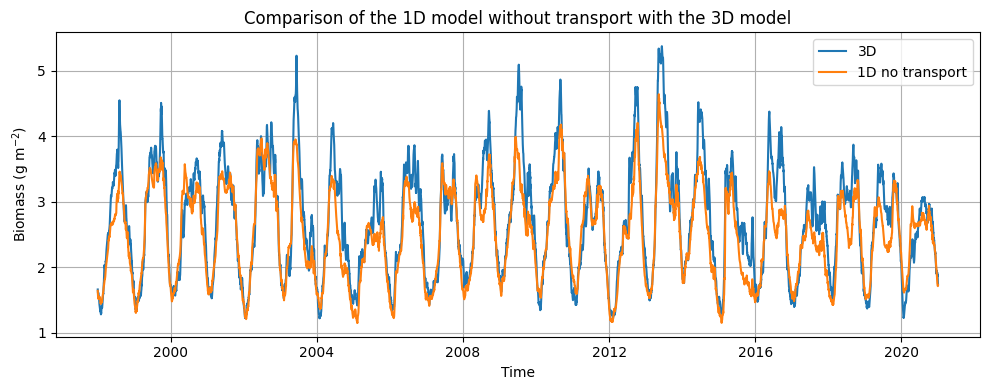

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(d3_biomass["time"], d3_biomass, label="3D")
plt.plot(d1_biomass["time"], d1_biomass, label="1D no transport")

plt.title("Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass (g m$^{-2}$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


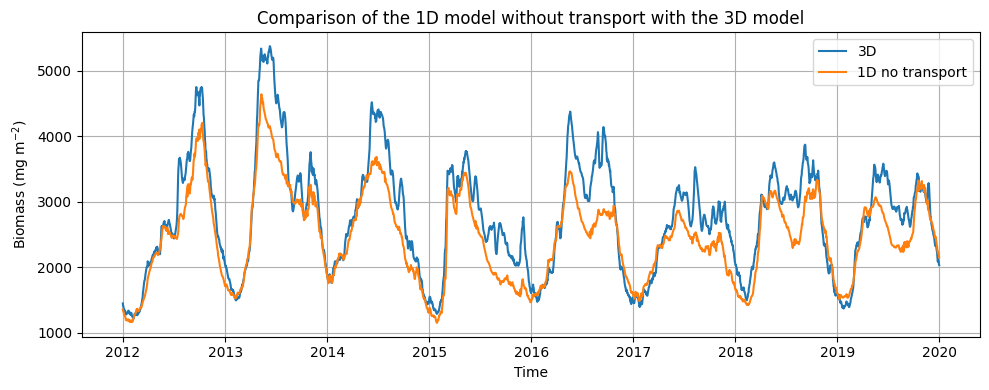

In [23]:
start_year="2012"
end_year="2019"

plt.figure(figsize=(10, 4))
plt.plot(d3_biomass["time"].sel(time=slice(start_year, end_year)), 
         d3_biomass.sel(time=slice(start_year, end_year)), label="3D")
plt.plot(d1_biomass["time"].sel(time=slice(start_year, end_year)), 
         d1_biomass.sel(time=slice(start_year, end_year)), label="1D no transport")

plt.title("Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass (mg m$^{-2}$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 2. Calculate the error metrics


In [25]:
diff=d3_biomass-d1_biomass

In [26]:
diff

<xarray.DataArray (time: 8401)> Size: 67kB
array([0.02148542, 0.03914826, 0.05437971, ..., 0.10733254, 0.06234529,
       0.01870219])
Coordinates:
  * time              (time) datetime64[ns] 67kB 1998-01-01 ... 2020-12-31
    latitude          int64 8B 0
    longitude         int64 8B 0
    functional_group  int64 8B 0

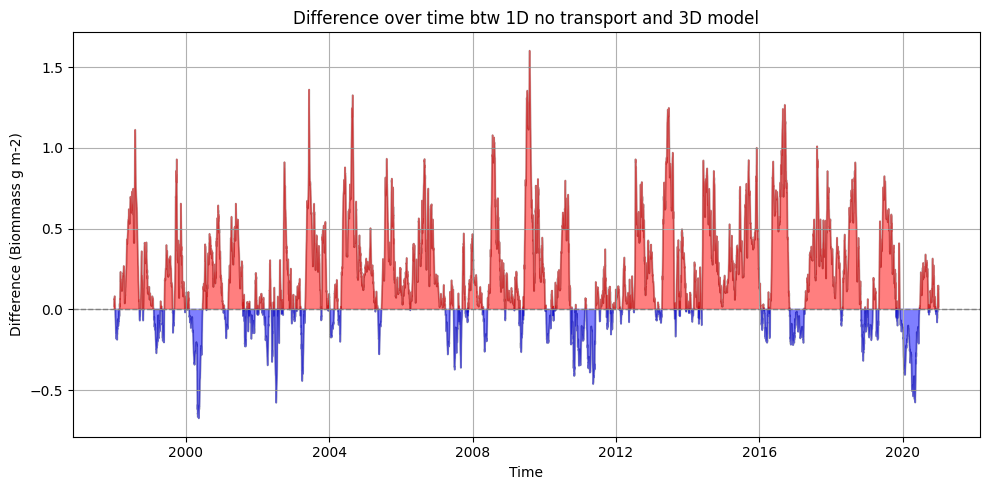

In [27]:
plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff["time"].values, diff.values, color="black",alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff > 0), interpolate=True, color="red", alpha=0.5)
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff < 0), interpolate=True, color="blue", alpha=0.5)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (Biommass g m-2)")
plt.title("Difference over time btw 1D no transport and 3D model")
plt.grid(True)
plt.tight_layout()
plt.show()


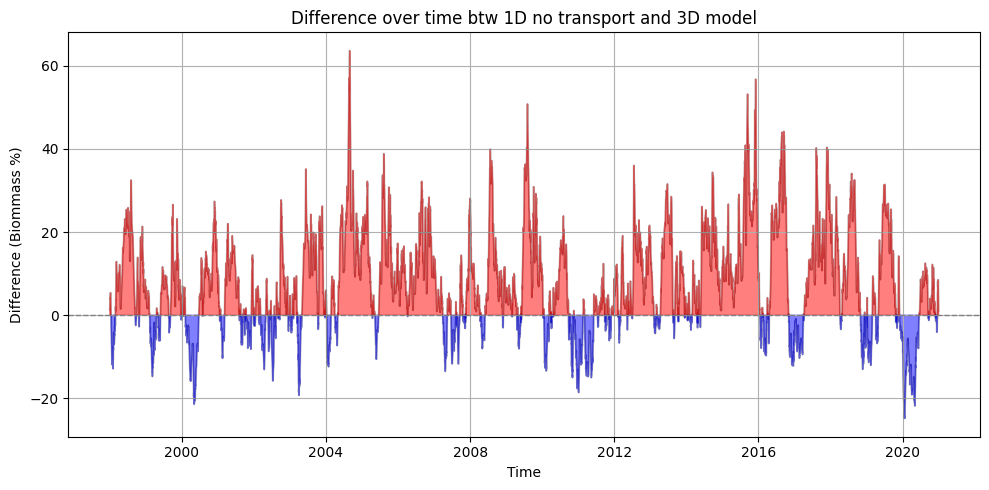

In [50]:
diff100=100*(d3_biomass-d1_biomass)/d1_biomass
plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff100["time"].values,diff100.values, color="black",alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(diff100["time"].values, diff100.values, 0, where=(diff100 > 0), interpolate=True, color="red", alpha=0.5)
plt.fill_between(diff100["time"].values, diff100.values, 0, where=(diff100 < 0), interpolate=True, color="blue", alpha=0.5)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (Biommass %)")
plt.title("Difference over time btw 1D no transport and 3D model")
plt.grid(True)
plt.tight_layout()
plt.show()


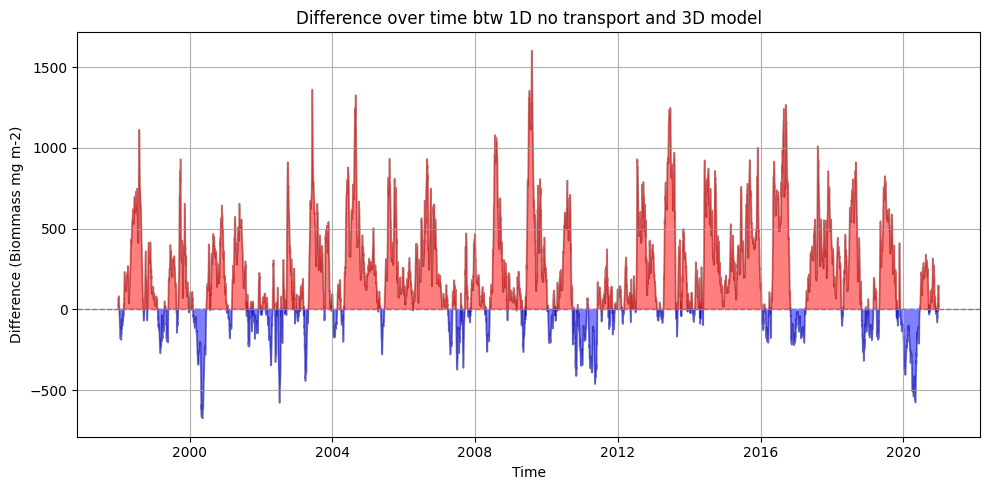

In [ ]:
plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff["time"].values, diff.values, color="black",alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff > 0), interpolate=True, color="red", alpha=0.5)
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff < 0), interpolate=True, color="blue", alpha=0.5)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (Biommass mg m-2)")
plt.title("Difference over time btw 1D no transport and 3D model")
plt.grid(True)
plt.tight_layout()
plt.show()


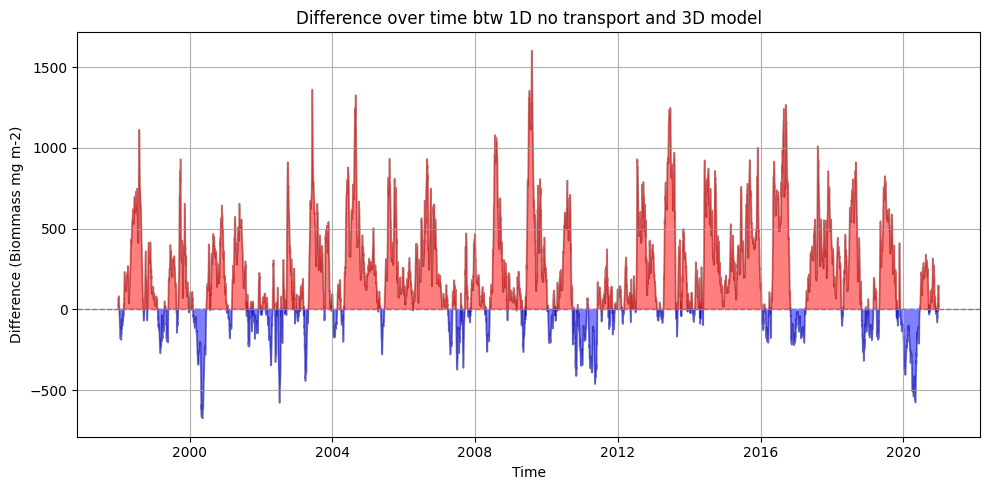

In [ ]:
plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff["time"].values, diff.values, color="black",alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff > 0), interpolate=True, color="red", alpha=0.5)
plt.fill_between(diff["time"].values, diff.values, 0, where=(diff < 0), interpolate=True, color="blue", alpha=0.5)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (Biommass mg m-2)")
plt.title("Difference over time btw 1D no transport and 3D model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
mean = diff.mean()
min_ = diff.min()
max_ = diff.max()
print("mean : ",mean.values)
print("min : ",min_.values)
print("max : ",max_.values)

mean :  207.49044996902649
min :  -675.1669843307955
max :  1602.4530910778376


### 3. GAM comparison

In [28]:
np.int = int  # Patch temporaire pour compatibilité pygam
from pygam import LinearGAM, s, l
import scipy.sparse
# Patch temporaire : ajoute un attribut `.A` à scipy.sparse matrices
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())

In [29]:
def decompose_GAM_xr(da):
    """
    Decompose time series from an xarray.DataArray using a GAM model into trend, seasonality, and residuals.

    Parameters:
        da (xarray.DataArray): .

    Returns:
        trend_da, season_da, residual_da : xarray.DataArray with the same time dimension as input
    """
    # Moyenne mensuelle
    da_monthly = (
        da
        .resample(time='ME')
        .mean()
        .dropna(dim='time')
    )
    # Convert to DataFrame
    df = da_monthly.dropna(dim='time').to_dataframe(name='value').reset_index()
    
    # Compute float time in days
    df['time_float'] = (df['time'] - df['time'].min()) / np.timedelta64(1, 'D')
    
    # Encode month as sin/cos
    df['month'] = df['time'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
    
    X = df[['time_float', 'month_sin', 'month_cos']].values
    y = df['value'].values
    
    gam = LinearGAM(s(0, n_splines=80) + l(1) + l(2), fit_intercept=False).fit(X, y)
    
    trend = gam.partial_dependence(term=0, X=X)
    season = gam.partial_dependence(term=1, X=X) + gam.partial_dependence(term=2, X=X)
    residuals = y - (trend + season)
    
    # Reconversion en xarray.DataArray
    time_coords = df['time'].values
    trend_da = xr.DataArray(trend, coords={'time': time_coords}, dims='time', name='trend')
    season_da = xr.DataArray(season, coords={'time': time_coords}, dims='time', name='season')
    residual_da = xr.DataArray(residuals, coords={'time': time_coords}, dims='time', name='residual')
    
    return trend_da, season_da, residual_da


In [30]:
d1_trend,d1_season,d1_residuals=decompose_GAM_xr(np.log10(d1_biomass))
d3_trend,d3_season,d3_residuals=decompose_GAM_xr(np.log10(d3_biomass))

In [31]:
def plot_GAM(da,df_trend,df_season,df_residuals):

    plt.figure(figsize=(14, 12))
    plt.subplot(4, 1, 1)
    plt.plot(da['time'], da.values, label='Observé')
    plt.legend()
    # plt.title()

    plt.subplot(4, 1, 2)
    plt.plot(df_trend['time'], df_trend.values, label='Tendance (splines)', color='red')
    plt.legend()
    plt.title('Tendance à long terme')

    plt.subplot(4, 1, 3)
    plt.plot(df_season['time'],df_season.values , label='Saisonnalité (mois)', color='orange')
    plt.legend()
    plt.title('Saisonnalité mensuelle')

    plt.subplot(4, 1, 4)
    plt.hlines(y=0, xmin=df_trend['time'][0],xmax=df_trend['time'][len(df_trend['time'])-1],color='grey')
    plt.plot(df_residuals['time'], df_residuals.values,'o', label='Résidus', color='gray')
    plt.legend()
    plt.title('Résidus')

    plt.tight_layout()
    plt.show()


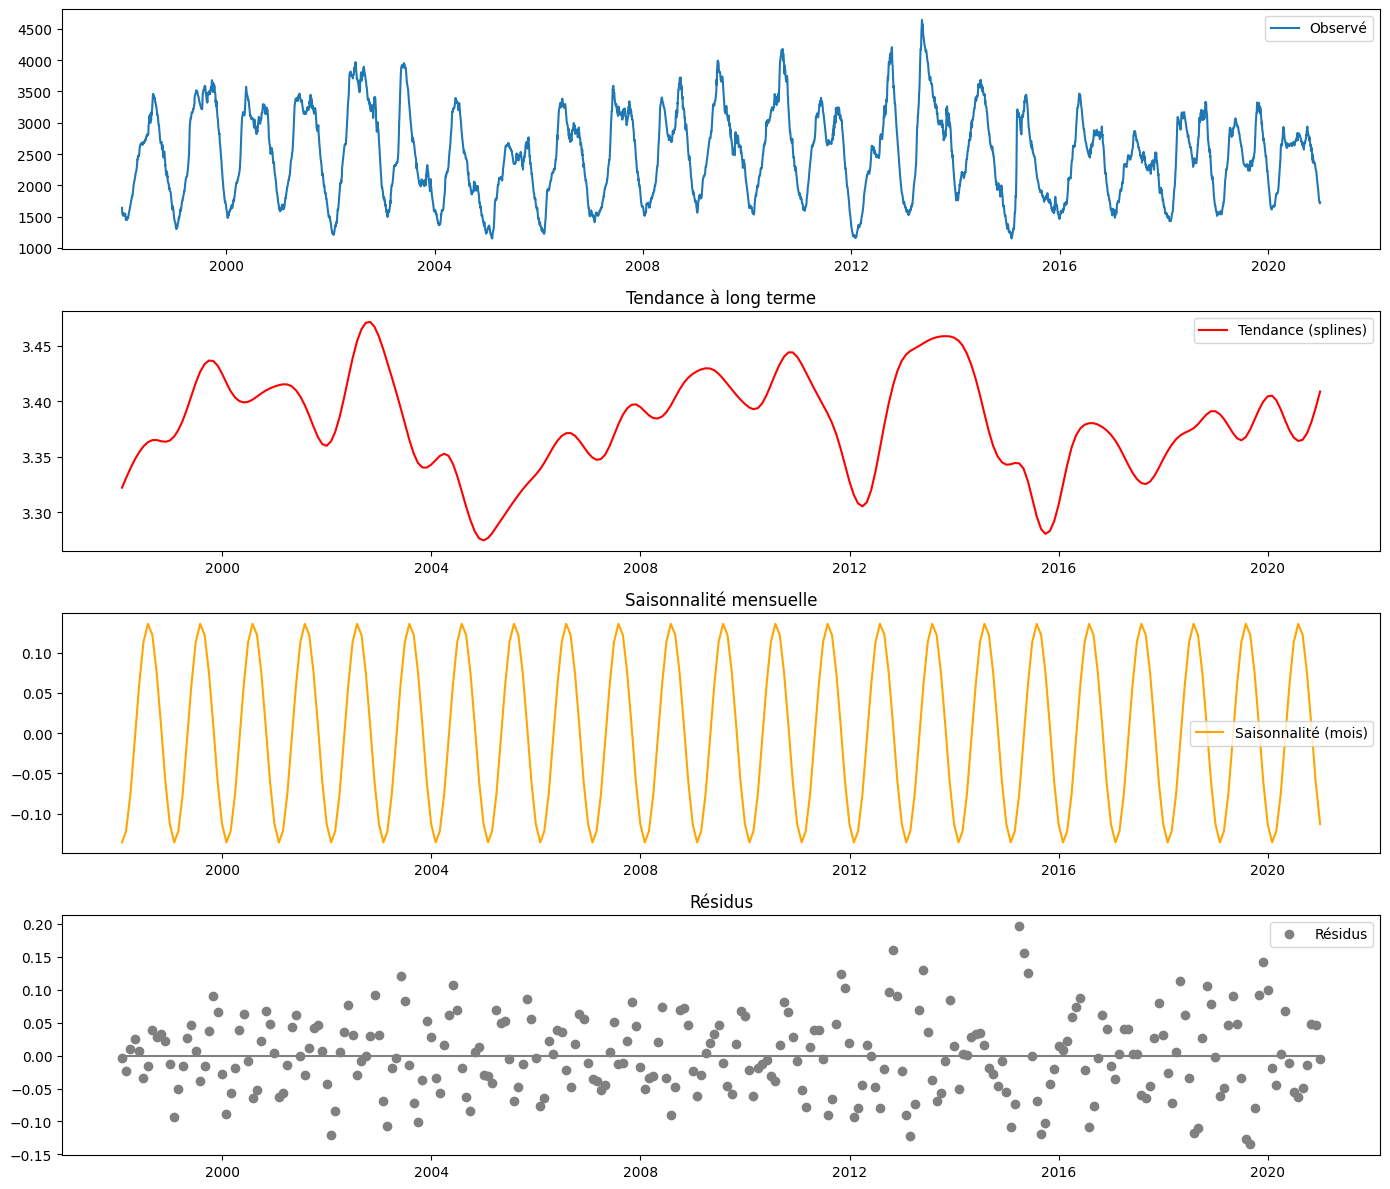

In [32]:
plot_GAM(d1_biomass,d1_trend,d1_season,d1_residuals)

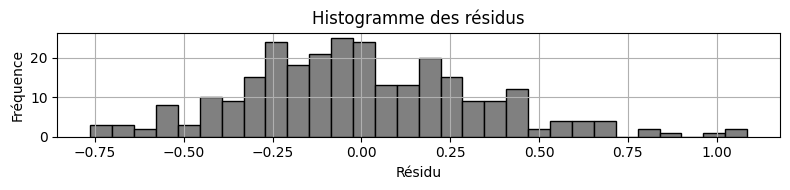

In [33]:
# Histogram residuals 1D
plt.figure(figsize=(8, 2))
plt.hist(d1_residuals, bins=30, color='gray', edgecolor='black')
plt.title('Histogramme des résidus')
plt.xlabel('Résidu')
plt.ylabel('Fréquence')
plt.grid(True)
plt.tight_layout()
plt.show()

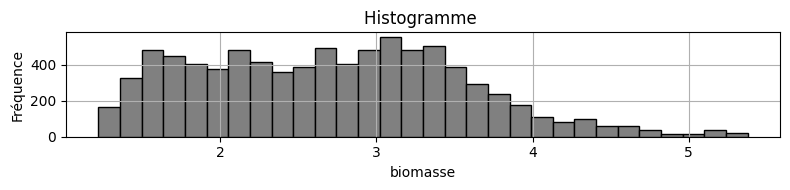

In [34]:

plt.figure(figsize=(8, 2))
plt.hist(d3_biomass, bins=30, color='gray', edgecolor='black')
plt.title('Histogramme ')
plt.xlabel('biomasse')
plt.ylabel('Fréquence')
plt.grid(True)
plt.tight_layout()
plt.show()

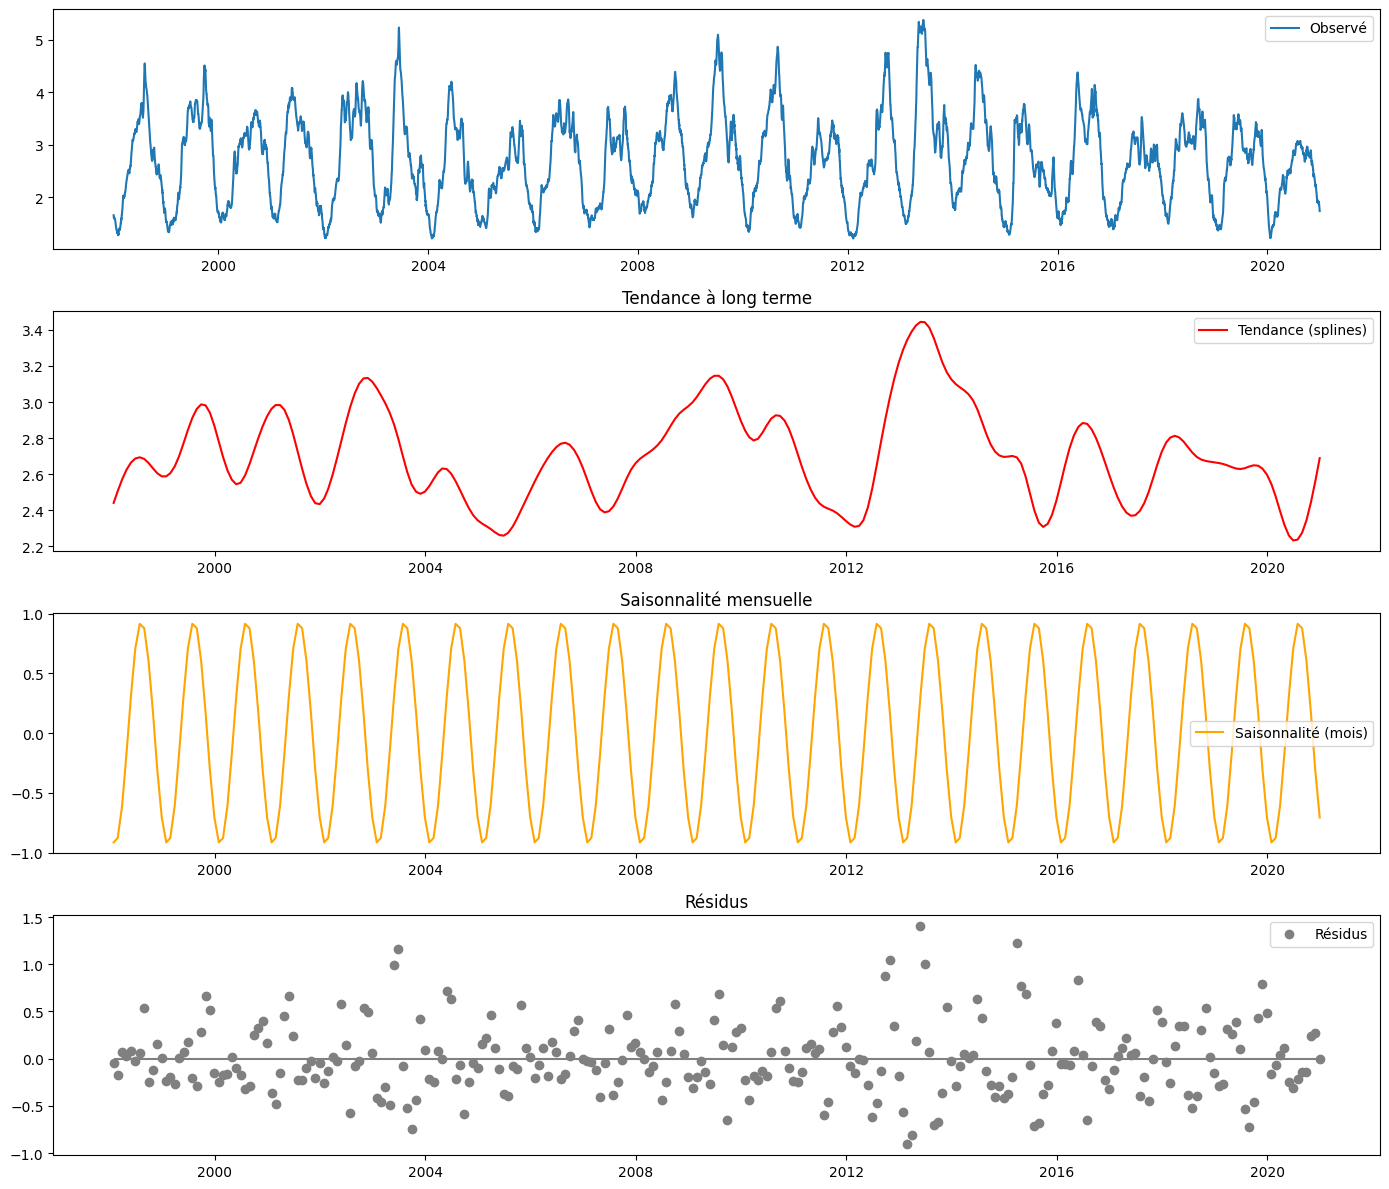

In [33]:
plot_GAM(d3_biomass,d3_trend,d3_season,d3_residuals)

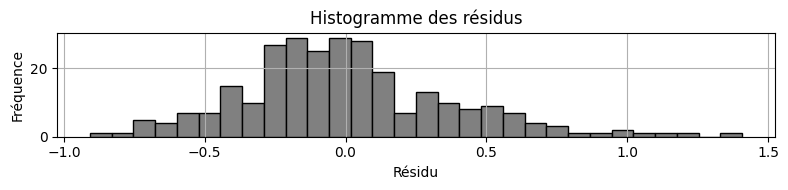

In [36]:
# Histogram residuals 3D
plt.figure(figsize=(8, 2))
plt.hist(d3_residuals, bins=30, color='gray', edgecolor='black')
plt.title('Histogramme des résidus')
plt.xlabel('Résidu')
plt.ylabel('Fréquence')
plt.grid(True)
plt.tight_layout()
plt.show()

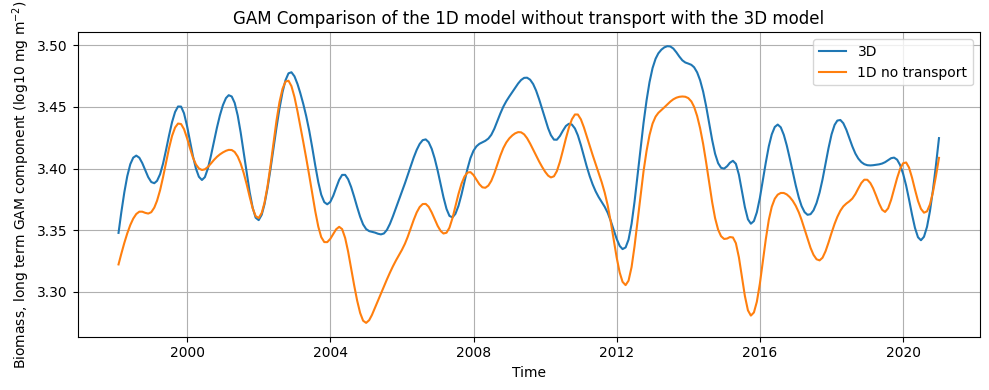

In [33]:
start_year="1998"
end_year="2020"

plt.figure(figsize=(10, 4))
plt.plot(d3_trend["time"].sel(time=slice(start_year, end_year)), 
         d3_trend.sel(time=slice(start_year, end_year)), label="3D")
plt.plot(d1_trend["time"].sel(time=slice(start_year, end_year)), 
         d1_trend.sel(time=slice(start_year, end_year)), label="1D no transport")

plt.title("GAM Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass, long term GAM component (log10 mg m$^{-2}$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


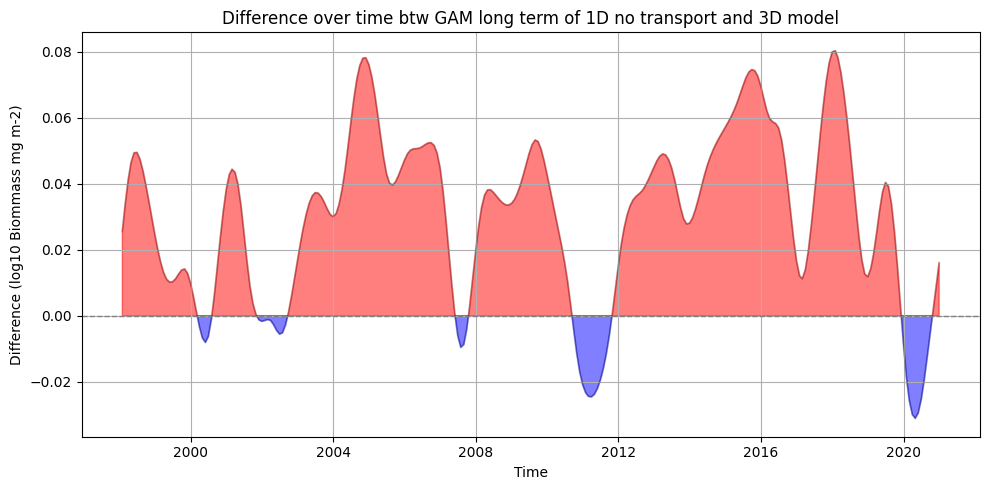

In [34]:
diff_trend=d3_trend-d1_trend
plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff_trend["time"].values, diff_trend.values, color="black",alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(diff_trend["time"].values, diff_trend.values, 0, where=(diff_trend > 0), interpolate=True, color="red", alpha=0.5)
plt.fill_between(diff_trend["time"].values, diff_trend.values, 0, where=(diff_trend < 0), interpolate=True, color="blue", alpha=0.5)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (log10 Biommass mg m-2)")
plt.title("Difference over time btw GAM long term of 1D no transport and 3D model")
plt.grid(True)
plt.tight_layout()
plt.show()


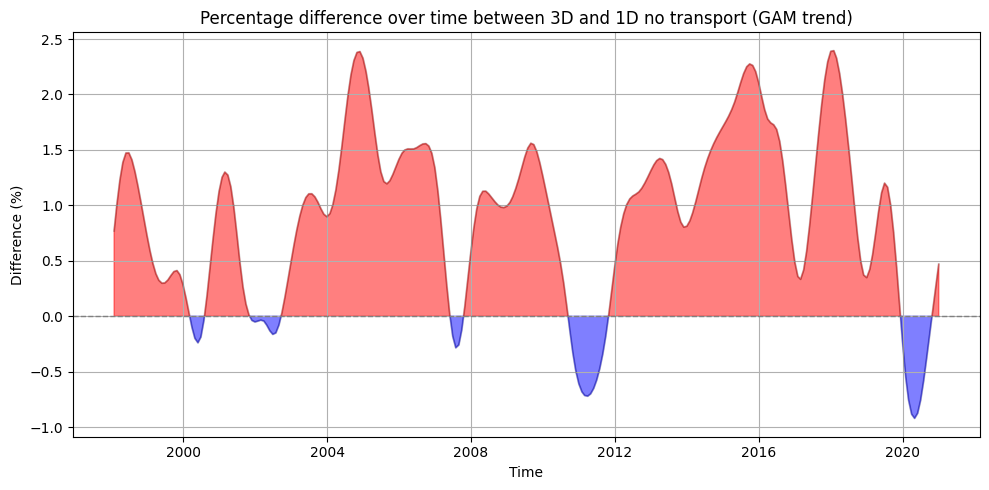

In [35]:
diff_percent = 100 * (d3_trend - d1_trend) / d1_trend

plt.figure(figsize=(10, 5))

# Trace la courbe
plt.plot(diff_percent["time"].values, diff_percent.values, color="black", alpha=0.2)

# Ligne y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Remplissage conditionnel
plt.fill_between(
    diff_percent["time"].values,
    diff_percent.values,
    0,
    where=(diff_percent > 0),
    interpolate=True,
    color="red",
    alpha=0.5
)
plt.fill_between(
    diff_percent["time"].values,
    diff_percent.values,
    0,
    where=(diff_percent < 0),
    interpolate=True,
    color="blue",
    alpha=0.5
)

# Mise en forme
plt.xlabel("Time")
plt.ylabel("Difference (%)")
plt.title("Percentage difference over time between 3D and 1D no transport (GAM trend)")
plt.grid(True)
plt.tight_layout()
plt.show()


### 4. Comparison with gam opti 1d (same forcings)

In [36]:
path_opti="../tests_pteropods/gam_decomposition_opti1Dlog.nc"
ds_opti = xr.open_dataset(path_opti,engine='netcdf4')

In [37]:
ds_opti

<xarray.Dataset> Size: 9kB
Dimensions:    (time: 274)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1998-03-01 1998-04-01 ... 2020-12-01
Data variables:
    trend      (time) float64 2kB ...
    season     (time) float64 2kB ...
    residuals  (time) float64 2kB ...
Attributes:
    title:    GAM decomposition of predicted biomass
    note:     All components are in log10 scale

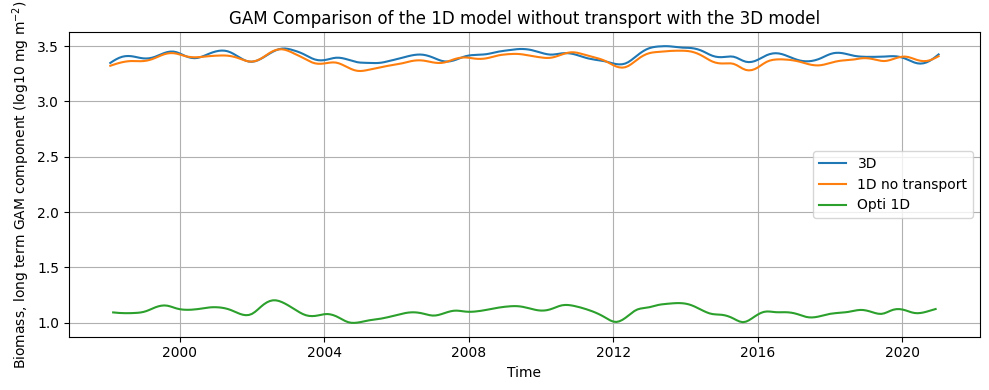

In [38]:
start_year="1998"
end_year="2020"

plt.figure(figsize=(10, 4))
plt.plot(d3_trend["time"].sel(time=slice(start_year, end_year)), 
         d3_trend.sel(time=slice(start_year, end_year)), label="3D")
plt.plot(d1_trend["time"].sel(time=slice(start_year, end_year)), 
         d1_trend.sel(time=slice(start_year, end_year)), label="1D no transport")
plt.plot(ds_opti["time"].sel(time=slice(start_year, end_year)), 
         ds_opti['trend'].sel(time=slice(start_year, end_year)), label="Opti 1D")

plt.title("GAM Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass, long term GAM component (log10 mg m$^{-2}$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


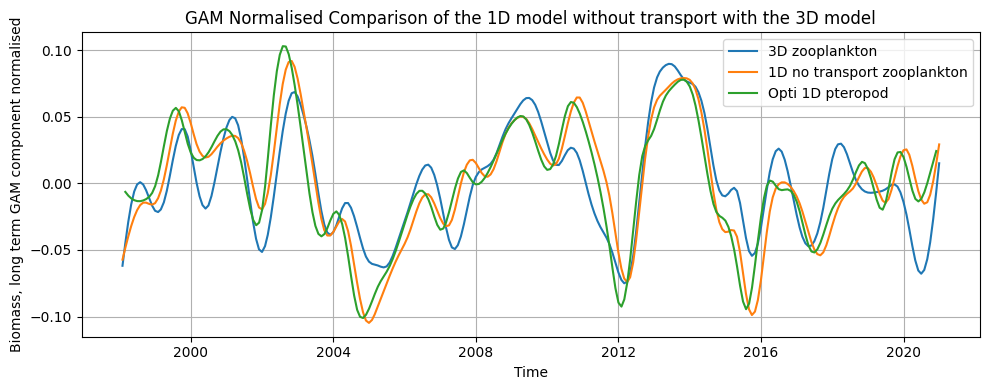

In [40]:
start_year="1998"
end_year="2020"

def normalize(da):
    return (da - da.mean())

plt.figure(figsize=(10, 4))
plt.plot(d3_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d3_trend.sel(time=slice(start_year, end_year))), label="3D zooplankton")
plt.plot(d1_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d1_trend.sel(time=slice(start_year, end_year))), label="1D no transport zooplankton")
plt.plot(ds_opti["time"].sel(time=slice(start_year, end_year)), 
         normalize(ds_opti['trend'].sel(time=slice(start_year, end_year))), label="Opti 1D pteropod")

plt.title("GAM Normalised Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass, long term GAM component normalised")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
path_obs="/data/rd_exchange/sroyer/SEAPOPYM/time_serie_pter_papa_1998_2020_clean_k_075.nc"
ds_obs = xr.open_dataset(path_obs,engine='netcdf4')
data_pter=ds_obs['pteropod_biomass_gm2']

In [42]:
obs_trend,obs_season,obs_residuals=decompose_GAM_xr(np.log10(data_pter))

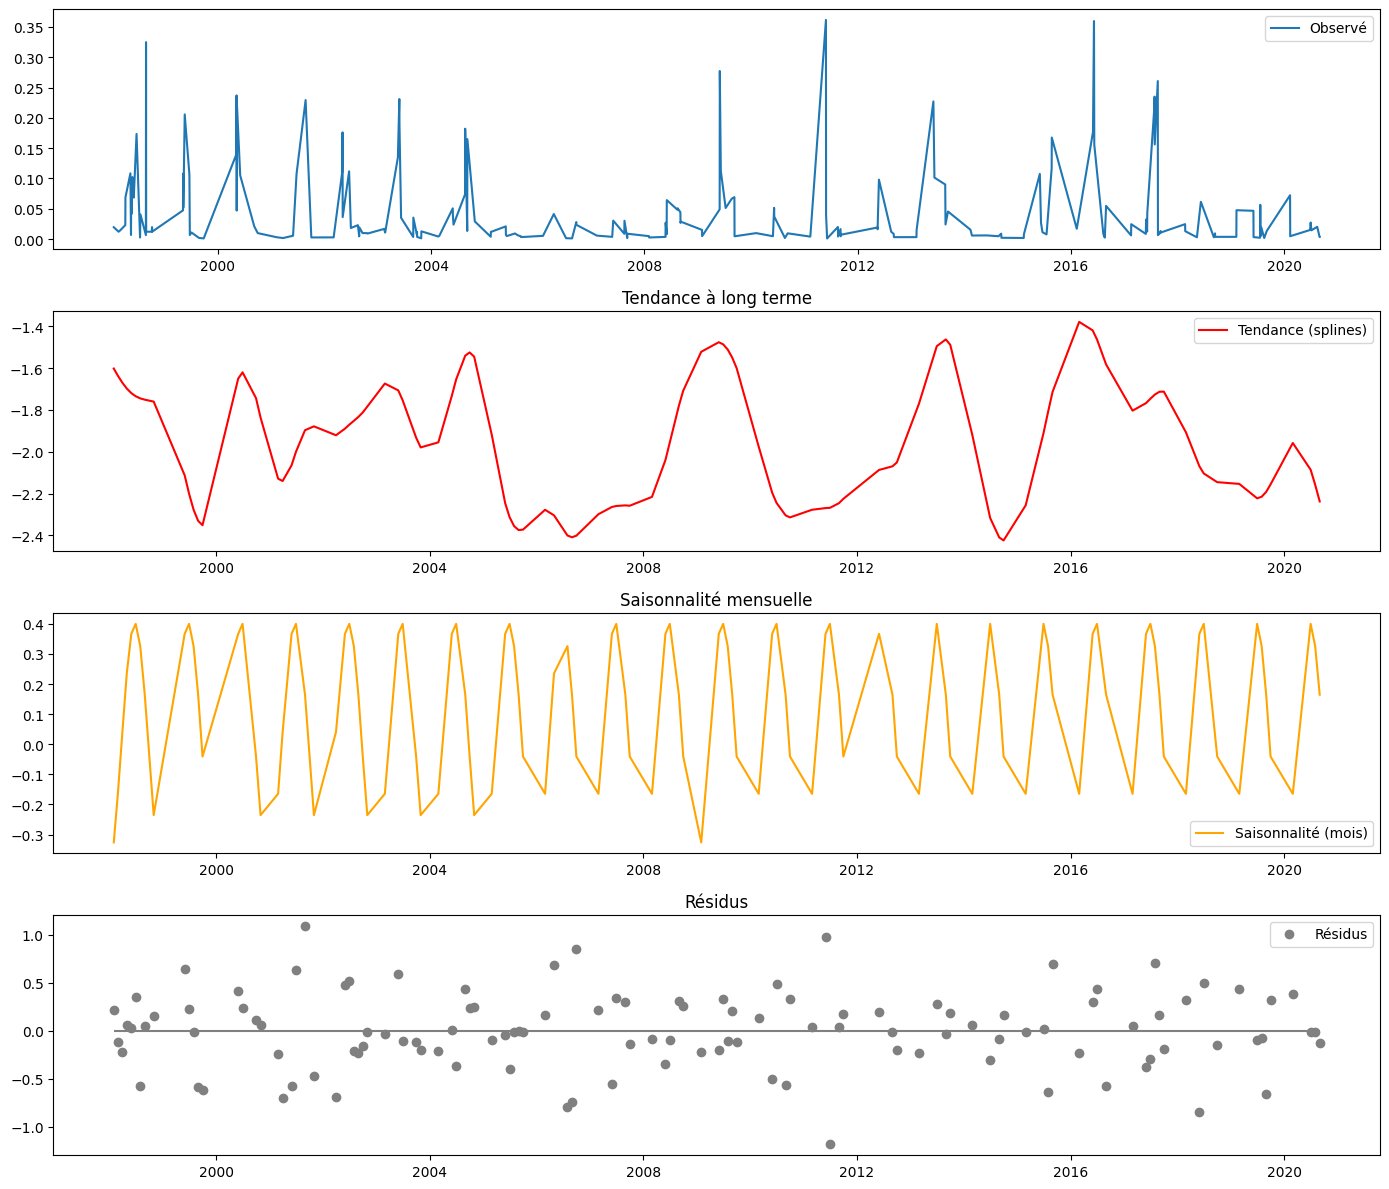

In [43]:
plot_GAM(data_pter,obs_trend,obs_season,obs_residuals)

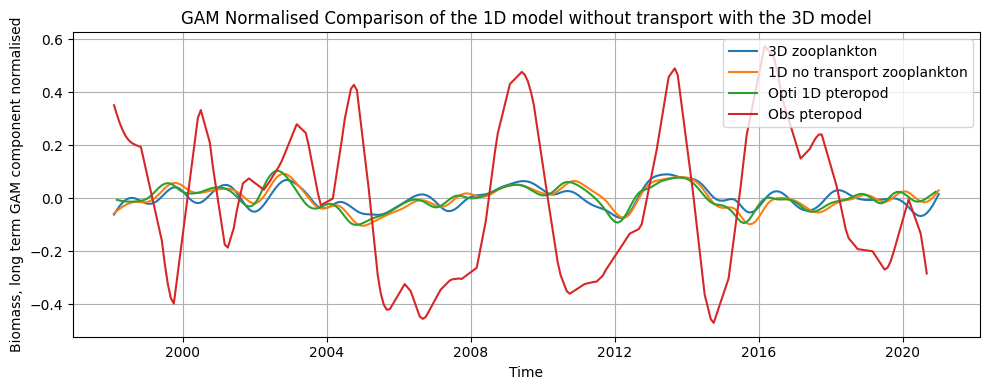

In [44]:
start_year="1998"
end_year="2020"

def normalize(da):
    return (da - da.mean()) 

plt.figure(figsize=(10, 4))
plt.plot(d3_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d3_trend.sel(time=slice(start_year, end_year))), label="3D zooplankton")
plt.plot(d1_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d1_trend.sel(time=slice(start_year, end_year))), label="1D no transport zooplankton")
plt.plot(ds_opti["time"].sel(time=slice(start_year, end_year)), 
         normalize(ds_opti['trend'].sel(time=slice(start_year, end_year))), label="Opti 1D pteropod")
plt.plot(obs_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(obs_trend.sel(time=slice(start_year, end_year))), label="Obs pteropod")

plt.title("GAM Normalised Comparison of the 1D model without transport with the 3D model")
plt.xlabel("Time")
plt.ylabel("Biomass, long term GAM component normalised")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


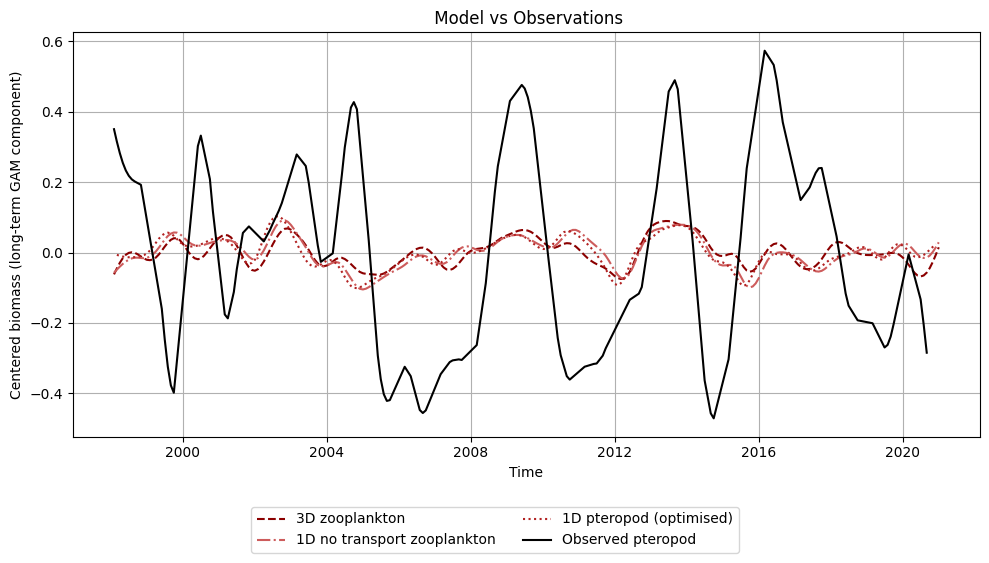

In [45]:
start_year = "1998"
end_year = "2020"

def normalize(da):
    return (da - da.mean()) 

fig=plt.figure(figsize=(10, 5))

# Courbes avec couleurs et styles différents
plt.plot(d3_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d3_trend.sel(time=slice(start_year, end_year))), 
         label="3D zooplankton", color="darkred", linestyle="--")
plt.plot(d1_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(d1_trend.sel(time=slice(start_year, end_year))), 
         label="1D no transport zooplankton", color="indianred", linestyle="-.")
plt.plot(ds_opti["time"].sel(time=slice(start_year, end_year)), 
         normalize(ds_opti['trend'].sel(time=slice(start_year, end_year))), 
         label="1D pteropod (optimised)", color="firebrick", linestyle=":")
plt.plot(obs_trend["time"].sel(time=slice(start_year, end_year)), 
         normalize(obs_trend.sel(time=slice(start_year, end_year))), 
         label="Observed pteropod", color="black")

# Mise en forme
plt.title(" Model vs Observations")
plt.xlabel("Time")
plt.ylabel("Centered biomass (long-term GAM component)")
plt.grid(True)
plt.tight_layout()


fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=2)

plt.show()
